![Imgur](https://i.imgur.com/acSOZRh.png)

# Laboratorio n° 1. Parte C: Denoising Autoencoder -- SOLUCION

**Asignatura:** Redes Neuronales Profundas
**Bloque:** 1 — Fundamentos de Deep Learning

---

## Introducción

En este laboratorio vas a construir un **denoising autoencoder**: una red neuronal que aprende a eliminar ruido de imágenes.

Este ejercicio integra todos los conceptos vistos en los laboratorios anteriores: creación de modelos con `nn.Sequential`, loops de entrenamiento y evaluación de redes.

---

## Instrucciones generales

- Las celdas de **setup** ya están escritas — ejecutálas sin modificar.
- Completá el código en las celdas marcadas con `# Tu código aquí`.
- Respondé las preguntas de análisis en las celdas de texto.

---
## Ejercicios

### ¿Qué es un autoencoder?

Imaginá que tenés que fotocopiar un documento, pero la fotocopiadora agrega ruido (manchas, rayaduras). ¿Podría una red neuronal aprender a "limpiar" las fotocopias recibiendo como entrada la copia sucia y comparando la salida con el original?

Sí, y esa es exactamente la idea de un **denoising autoencoder** (autocodificador de eliminación de ruido).

Un autoencoder tiene dos partes:

```
imagen ruidosa → [ ENCODER ] → vector latente → [ DECODER ] → imagen reconstruida
```

![Imgur](https://i.imgur.com/iOp5Vdu.png)

**El Encoder** comprime la imagen en un vector de menor dimensión llamado **espacio latente**. La idea es que ese vector capture solo la información esencial de la imagen (la prenda, su forma, su textura), descartando el ruido, que es aleatorio y no tiene estructura.

**El Decoder** toma ese vector comprimido y reconstruye la imagen original sin ruido.

La red se entrena con la siguiente lógica:
- **Entrada:** imagen con ruido
- **Salida esperada (etiqueta):** imagen **sin** ruido
- **Función de pérdida:** error cuadrático medio (MSE) entre la imagen reconstruida y la original

Al minimizar ese error, la red aprende a comprimir solo la información relevante y a ignorar el ruido.

#### Setup — importaciones y datos

Fijamos `torch.manual_seed(42)` para reproducibilidad: garantiza los mismos resultados en cada ejecución (misma inicialización de pesos, mismo orden de datos en el *shuffle*).

Utilizaremos nuevamente el dataset FashionMNIST. Sabemos que este dataset tiene etiquetas de clase (prenda de ropa), pero en este laboratorio las **ignoramos** — se representan con `_` al iterar. La "etiqueta" aquí son las propias imágenes originales sin ruido.

In [45]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils import data
import matplotlib.pyplot as plt

torch.manual_seed(42)
batch_size = 256

mnist_train = torchvision.datasets.FashionMNIST(
    root="./data", train=True, transform=transforms.ToTensor(), download=True
)
mnist_test = torchvision.datasets.FashionMNIST(
    root="./data", train=False, transform=transforms.ToTensor(), download=True
)

# shuffle=True: mezcla los lotes en cada época para mejorar la generalización.
iter_train = data.DataLoader(mnist_train, batch_size, shuffle=True)
iter_valid = data.DataLoader(mnist_test, batch_size, shuffle=False)

print(f"PyTorch {torch.__version__}")
print(f"Entrenamiento: {len(mnist_train)} imágenes | Prueba: {len(mnist_test)} imágenes")

PyTorch 2.10.0
Entrenamiento: 60000 imágenes | Prueba: 10000 imágenes


#### Generador de ruido de Dropout

Usamos `nn.Dropout(p=0.5)` como generador de ruido: con esa probabilidad, apaga (pone en 0) cada píxel de la imagen al azar. El efecto visual es que la mitad de los píxeles se vuelven negros.

> **Importante:** `nn.Dropout` solo actúa en modo entrenamiento (`.train()`). En modo evaluación (`.eval()`), el autoencoder **no modifica** la imagen. Esto es el comportamiento deseado: en producción las imágenes ya llegan limpias y deben pasar sin alteración.

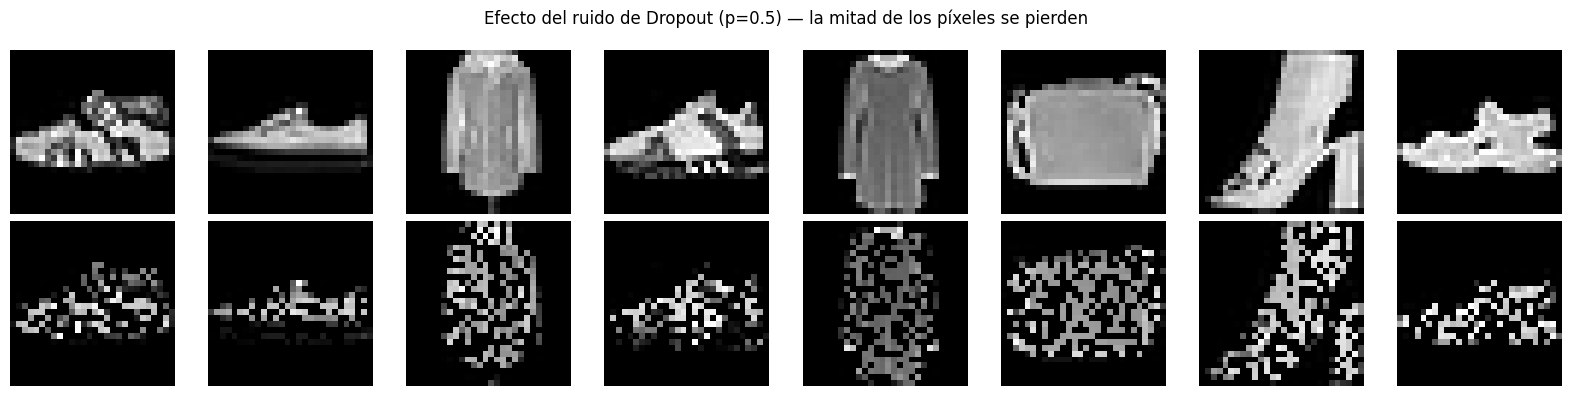

In [46]:
p = 0.5
noise = nn.Sequential(nn.Dropout(p))

images, _ = next(iter(iter_train))
noise.train()  # Dropout solo actúa en modo train
noise_images = noise(images)

n = 8
fig, axes = plt.subplots(2, n, figsize=(n * 2, 4))
for i in range(n):
    axes[0, i].imshow(images[i].squeeze(), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(noise_images[i].squeeze(), cmap="gray")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("Con ruido", fontsize=12)
plt.suptitle("Efecto del ruido de Dropout (p=0.5) — la mitad de los píxeles se pierden")
plt.tight_layout()
plt.show()

### Ejercicio 1 — Construir el Encoder

**Objetivo:** Definir la mitad "compresora" del autoencoder.

**Enunciado:**

El encoder debe:
1. Tomar como entrada una imagen de 28×28 píxeles (aplanada en un vector de 784 elementos).
2. Pasarla por una capa oculta de **100 neuronas** con activación ReLU.
3. Producir un vector latente de **30 elementos**.

Guardá el encoder en la variable `encoder`.

> **Pista:** Usá `nn.Sequential` con las capas en orden: `Flatten → Linear(784, 100) → ReLU → Linear(100, 30)`

In [47]:
# Flatten:         (batch, 1, 28, 28) → (batch, 784)
# Linear(784,100): (batch, 784)       → (batch, 100)
# ReLU:            introduce no-linealidad; sin ella, dos lineales son equivalentes a una sola.
# Linear(100, 30): (batch, 100)       → (batch, 30)  ← espacio latente

encoder = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 100),
    nn.ReLU(),
    nn.Linear(100, 30)
)

In [28]:
# Test automático del encoder — ejecutar sin modificar
images, _ = next(iter(iter_train))
try:
    latentes = encoder(images)
    assert latentes.shape[1] == 30, f"La salida del encoder debería tener 30 elementos, tiene {latentes.shape[1]}"
    print(f"Encoder OK: entrada {images.shape} -> latentes {latentes.shape}")
except Exception as e:
    print(f"Error: {e}")

Encoder OK: entrada torch.Size([256, 1, 28, 28]) -> latentes torch.Size([256, 30])


**Pregunta de análisis:**

¿Por qué es necesaria la activación ReLU entre las dos capas lineales del encoder? ¿Qué pasaría si la quitáramos?

*(Escribí tu respuesta acá)*

**Respuesta a la pregunta de análisis:**

Sin ReLU, la composición de dos capas lineales `Linear(784,100)` seguida de `Linear(100,30)` es matemáticamente equivalente a una única capa `Linear(784,30)`. Esto es porque la composición de transformaciones lineales es siempre una transformación lineal. La red perdería su capacidad de aprender representaciones no lineales de los datos.

ReLU introduce la no-linealidad necesaria para que el encoder pueda capturar patrones complejos de la imagen (bordes, texturas, formas) que no son separables linealmente.

### Ejercicio 2 — Construir el Decoder

**Objetivo:** Definir la mitad "reconstructora" del autoencoder.

**Enunciado:**

El decoder es el proceso inverso del encoder:
1. Recibe como entrada el vector latente de **30 elementos**.
2. Lo expande a través de una capa oculta de **100 neuronas** con activación ReLU.
3. Produce como salida una imagen reconstruida de **28×28** píxeles.

Guardá el decoder en la variable `decoder`.


In [29]:
# Linear(30, 100):     (batch, 30)  → (batch, 100)  ← expansión
# Linear(100, 784):    (batch, 100) → (batch, 784)  ← todos los píxeles
# Unflatten(1,(28,28)): (batch, 784) → (batch, 28, 28) ← vuelve a imagen

decoder = nn.Sequential(
    nn.Linear(30, 100),
    nn.ReLU(),
    nn.Linear(100, 784),
    nn.Unflatten(1, (28, 28))
)

In [30]:
# Test automático del decoder — ejecutar sin modificar
try:
    salidas = decoder(latentes)
    assert salidas.shape[1] == 28 and salidas.shape[2] == 28, \
        f"La salida del decoder debería ser (batch, 28, 28), es {salidas.shape}"
    print(f"Decoder OK: latentes {latentes.shape} -> salida {salidas.shape}")
except Exception as e:
    print(f"Error: {e}")

Decoder OK: latentes torch.Size([256, 30]) -> salida torch.Size([256, 28, 28])


### Ejercicio 3 — Ensamblar el Autoencoder

**Objetivo:** Conectar el generador de ruido, el encoder y el decoder en una única red.

**Enunciado:**

El autoencoder completo debe encadenar (`nn.Sequential`) los tres bloques en orden:
```
imagen → [noise] → [encoder] → [decoder] → imagen reconstruida
```

Guardalo en la variable `net_ae`.


In [31]:
net_ae = nn.Sequential(noise, encoder, decoder)

In [32]:
# Test automático del autoencoder — ejecutar sin modificar
try:
    net_ae.train()
    salida_ae = net_ae(images)
    assert salida_ae.shape == images[:, 0].shape, \
        f"La salida debería ser (batch, 28, 28), es {salida_ae.shape}"
    print(f"Autoencoder OK: entrada {images.shape} -> salida {salida_ae.shape}")
except Exception as e:
    print(f"Error: {e}")

Autoencoder OK: entrada torch.Size([256, 1, 28, 28]) -> salida torch.Size([256, 28, 28])


**Pregunta de análisis:**

El bloque `noise` corrompe la imagen antes de pasarla al encoder. Sin embargo, la función de pérdida compara la salida del decoder con la imagen **original** (sin ruido). ¿Por qué esta asimetría es la clave para que la red aprenda a eliminar ruido?

*(Escribí tu respuesta acá)*

**Respuesta a la pregunta de análisis:**

Esta asimetría es exactamente la que le enseña a la red a eliminar ruido. El proceso es:

1. `noise(imagen_original)` → `imagen_ruidosa`: corrompemos la imagen a propósito.
2. `encoder(imagen_ruidosa)` → `vector_latente`: la red intenta extraer la información esencial de la imagen sucia.
3. `decoder(vector_latente)` → `imagen_reconstruida`: la red intenta reconstruir una imagen.
4. `MSELoss(imagen_reconstruida, imagen_original)`: el error se calcula contra la imagen **limpia**.

Al minimizar ese error, la red aprende que el camino más corto para tener una salida limpia a partir de una entrada sucia es **ignorar el ruido** (que es aleatorio y no tiene estructura) y quedarse solo con la información de la imagen subyacente. El cuello de botella del espacio latente (30 dimensiones vs. 784 de la imagen) fuerza a que la red no pueda "guardar" el ruido: debe comprimir y priorizar.

### Ejercicio 4 — Definir pérdida y optimizador

**Objetivo:** Elegir la función de pérdida adecuada para un autoencoder.

**Enunciado:**

1. Instanciá la pérdida `nn.MSELoss()` y guardála en `loss_ae`.
2. Instanciá el optimizador `torch.optim.Adam(net_ae.parameters())` y guardálo en `trainer_ae`.

In [33]:
# MSELoss: compara valores numéricos continuos (píxeles entre 0 y 1).
# CrossEntropyLoss está diseñado para clasificación (clases discretas), no para píxeles.
loss_ae = nn.MSELoss()

# Adam adapta el lr por parámetro según su historial de gradientes,
# lo que lo hace más robusto que SGD y suele converger más rápido.
trainer_ae = torch.optim.Adam(net_ae.parameters())
print("Pérdida y optimizador configurados.")

Pérdida y optimizador configurados.


**Pregunta de análisis:**

1. ¿Por qué usamos `MSELoss` y no `CrossEntropyLoss` para el autoencoder? ¿Cuál es la diferencia conceptual entre ambas?
2. Adam es un optimizador más sofisticado que SGD. ¿Qué ventaja tiene sobre SGD puro?

*(Escribí tu respuesta acá)*

**Respuesta a la pregunta de análisis:**

**1. MSELoss vs CrossEntropyLoss:**
- `CrossEntropyLoss` compara una **distribución de probabilidades predicha** contra una **clase discreta**. Solo tiene sentido para clasificación.
- `MSELoss` compara **valores numéricos**: `L = (y_pred - y_real)²`. Es la función natural cuando la salida es continua (como los valores de píxeles entre 0 y 1).

**2. Adam vs SGD:**
SGD actualiza todos los parámetros con el mismo lr global: `w ← w - lr * grad`. Adam, en cambio, mantiene un historial de gradientes para cada parámetro y adapta el lr de cada uno individualmente. Esto lo hace mucho más robusto y suele converger en menos épocas.

### Ejercicio 5 — Entrenar el autoencoder

**Objetivo:** Implementar el loop de entrenamiento para el autoencoder.

**Enunciado:**

Este bucle es similar al del Laboratorio 1b, con una diferencia importante: **la etiqueta no son clases, sino las imágenes originales sin ruido**. El objetivo es que la salida del modelo se parezca a la imagen de entrada.

1. Poné el modelo en modo entrenamiento (`net_ae.train()`)
2. Para cada lote `(images, _)` del `iter_train`:
   - Calculá la pérdida entre `net_ae(images)` y las imágenes originales.
   - **Atención con las formas:** `images` del DataLoader tiene forma `(B, 1, 28, 28)`. Si tu decoder termina en `nn.Linear`, la salida es `(B, 784)` y tenés que comparar contra `images.view(-1, 784)`. Si termina en `nn.Unflatten(1, (28, 28))`, la salida es `(B, 28, 28)` y comparás contra `images.squeeze(1)`.
   - Seguí los 4 pasos: `zero_grad → backward → step`
3. Entrenás por **50 épocas** (puede tardar unos minutos).
4. Visualizá las imágenes reconstruidas con la función `plot_reconstructions` provista abajo.


In [34]:
num_epochs_ae = 50

for epoch in range(num_epochs_ae):
    net_ae.train()  # Dropout activo: apaga píxeles al azar en cada lote
    perdida_epoch = 0.0
    n = 0

    for images, _ in iter_train:
        reconstruida = net_ae(images)               # forward: noise → encoder → decoder
        target = images.squeeze(1)                  # (batch,1,28,28) → (batch,28,28)
        l = loss_ae(reconstruida, target)            # MSE contra la imagen ORIGINAL (sin ruido)

        trainer_ae.zero_grad()
        l.backward()
        trainer_ae.step()

        perdida_epoch += l.item() * images.size(0)
        n += images.size(0)

    if (epoch + 1) % 10 == 0:
        print(f"Época {epoch+1:3d} | pérdida media: {perdida_epoch/n:.6f}")

print("\nEntrenamiento finalizado.")

Época  10 | pérdida media: 0.018529
Época  20 | pérdida media: 0.017387
Época  30 | pérdida media: 0.016906
Época  40 | pérdida media: 0.016596
Época  50 | pérdida media: 0.016350

Entrenamiento finalizado.


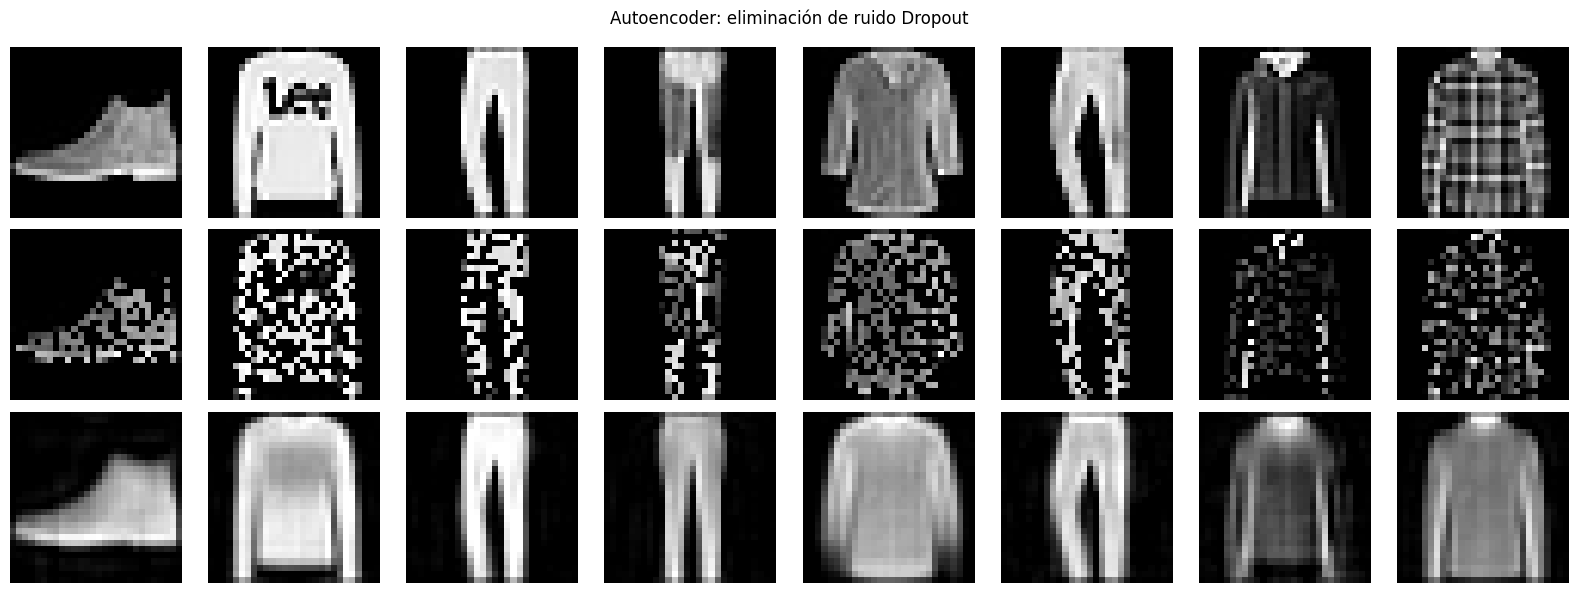

In [35]:
# Visualización de reconstrucciones — ejecutar sin modificar
import numpy as np

def plot_reconstructions(model, images, n=8):
    """
    Muestra imágenes originales, con ruido y reconstruidas por el modelo.

    Parámetros:
    model: el autoencoder entrenado (net_ae)
    images: lote de imágenes sin ruido
    n: número de imágenes a mostrar
    """
    # Generamos ruido externamente (para poder mostrarlo)
    ruido = nn.Sequential(nn.Dropout(0.5))
    ruido.train()
    noisy = ruido(images[:n])

    # En eval(), el Dropout del modelo está desactivado —
    # equivale a saltearse el bloque noise del autoencoder.
    # Pasamos la imagen ruidosa directamente al modelo completo.
    model.eval()
    with torch.no_grad():
        recon = model(noisy)
    model.train()

    fig, axes = plt.subplots(3, n, figsize=(n * 2, 6))
    for i in range(n):
        axes[0, i].imshow(images[i].squeeze(), cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(noisy[i].squeeze().detach(), cmap="gray")
        axes[1, i].axis("off")
        axes[2, i].imshow(recon[i].squeeze().detach().clamp(0, 1), cmap="gray")
        axes[2, i].axis("off")
    axes[0, 0].set_ylabel("Original", fontsize=11)
    axes[1, 0].set_ylabel("Con ruido Dropout", fontsize=11)
    axes[2, 0].set_ylabel("Reconstruida", fontsize=11)
    plt.suptitle("Autoencoder: eliminación de ruido Dropout")
    plt.tight_layout()
    plt.show()

images_val, _ = next(iter(iter_valid))
plot_reconstructions(net_ae, images_val)

### Ejercicio 6 — Ruido gaussiano con un módulo personalizado

**Objetivo:** Reemplazar el bloque `noise` (basado en Dropout) por un módulo personalizado que agregue ruido gaussiano, usando herencia de `nn.Module`.

**Enunciado:**

El **ruido gaussiano** agrega a cada píxel un valor aleatorio extraído de una distribución normal — en lugar de apagarlo como hace Dropout. Esto simula mejor el ruido de cámaras o sensores reales.

El ruido solo debe aplicarse durante el entrenamiento: cuando `self.training == True`. Durante la evaluación, las imágenes deben pasar sin modificación.

> **Pistas:**
> - Creá una clase `GaussianNoise(nn.Module)` con parámetros `mean` y `std`.
> - En el método `forward`, verificá `self.training` para decidir si aplicar ruido.
> - El ruido gaussiano se genera con `torch.randn_like(tensor) * std + mean`.
> - Re-ensamblar el autoencoder con este nuevo bloque y re-entrenarlo.

In [38]:
class GaussianNoise(nn.Module):
    """
    Capa que agrega ruido gaussiano a un tensor durante el entrenamiento.

    Al heredar de nn.Module, se integra con los modos .train() y .eval()
    y puede usarse dentro de nn.Sequential como cualquier otra capa.

    Parámetros:
    mean (float): media del ruido gaussiano (habitualmente 0)
    std (float): desviación estándar del ruido (controla la intensidad)
    """

    def __init__(self, mean=0.0, std=0.15):
        super().__init__()  # registra la capa correctamente en PyTorch
        self.mean = mean
        self.std = std

    def forward(self, x):
        # self.training se activa con .train() y se desactiva con .eval()
        if self.training:
            ruido = torch.randn_like(x) * self.std + self.mean
            return x + ruido
        else:
            return x  # en evaluación, la imagen pasa sin modificación


noise_gaussian = GaussianNoise(mean=0.0, std=0.15)

# Encoder y decoder nuevos para no compartir pesos con el modelo anterior
encoder_g = nn.Sequential(nn.Flatten(), nn.Linear(784, 100), nn.ReLU(), nn.Linear(100, 30))
decoder_g = nn.Sequential(nn.Linear(30, 100), nn.ReLU(), nn.Linear(100, 784), nn.Unflatten(1, (28, 28)))
net_gaussian = nn.Sequential(noise_gaussian, encoder_g, decoder_g)

trainer_g = torch.optim.Adam(net_gaussian.parameters())

print("Entrenando autoencoder con ruido gaussiano...")
for epoch in range(50):
    net_gaussian.train()
    perdida_epoch = 0.0
    n = 0
    for images, _ in iter_train:
        reconstruida = net_gaussian(images)
        target = images.squeeze(1)              # (batch,1,28,28) → (batch,28,28)
        l = loss_ae(reconstruida, target)
        trainer_g.zero_grad()
        l.backward()
        trainer_g.step()
        perdida_epoch += l.item() * images.size(0)
        n += images.size(0)
    if (epoch + 1) % 10 == 0:
        print(f"Época {epoch+1:3d} | pérdida media: {perdida_epoch/n:.6f}")

print("\nEntrenamiento finalizado.")


Entrenando autoencoder con ruido gaussiano...
Época  10 | pérdida media: 0.014984
Época  20 | pérdida media: 0.014074
Época  30 | pérdida media: 0.013573
Época  40 | pérdida media: 0.013255
Época  50 | pérdida media: 0.013021

Entrenamiento finalizado.


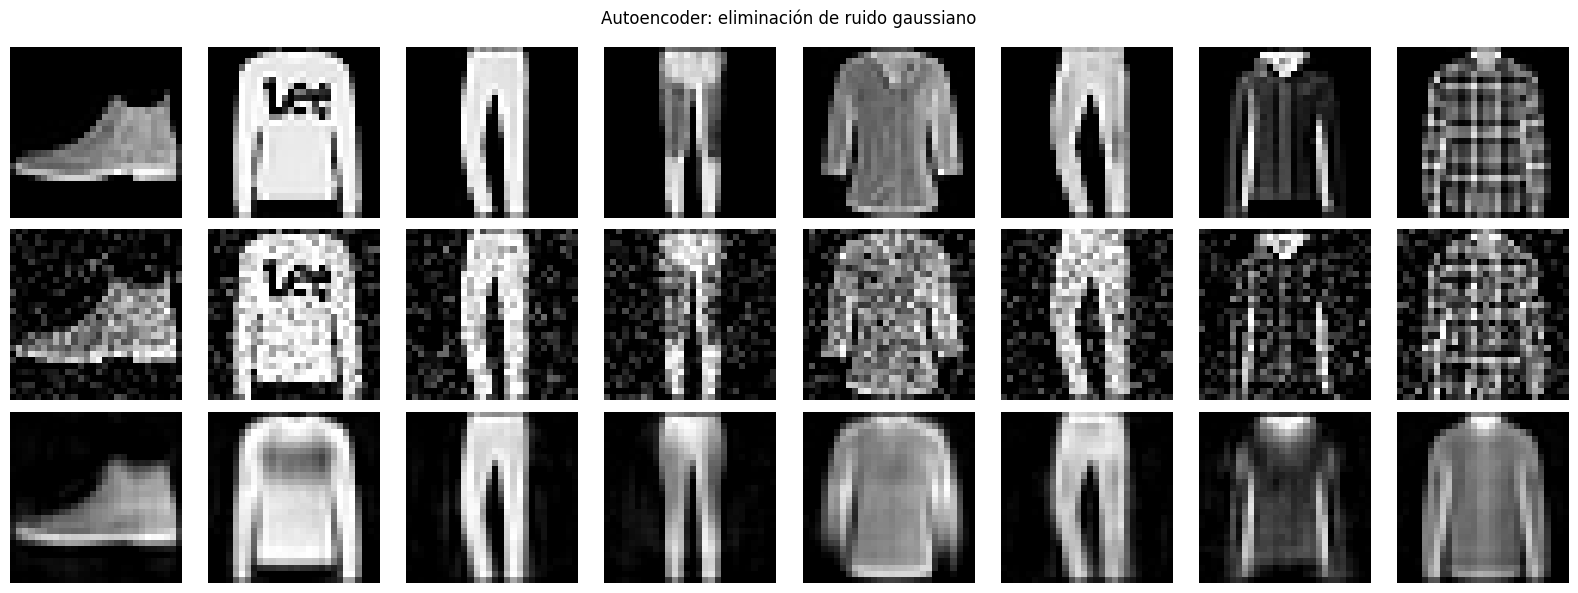

In [40]:
# Visualización del autoencoder gaussiano — ejecutar sin modificar
def plot_reconstructions_gaussian(model, images, n=8):
    """
    Muestra imágenes originales, con ruido gaussiano y reconstruidas.

    Parámetros:
    model: el autoencoder entrenado con ruido gaussiano
    images: lote de imágenes sin ruido
    n: número de imágenes a mostrar
    """
    ruido = GaussianNoise(mean=0.0, std=0.15)
    ruido.train()
    noisy = ruido(images[:n])

    # En eval(), GaussianNoise no aplica ruido (self.training == False)
    # Pasamos la imagen ruidosa directamente al modelo completo.
    model.eval()
    with torch.no_grad():
        recon = model(noisy)
    model.train()

    fig, axes = plt.subplots(3, n, figsize=(n * 2, 6))
    for i in range(n):
        axes[0, i].imshow(images[i].squeeze(), cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(noisy[i].squeeze().detach().clamp(0, 1), cmap="gray")
        axes[1, i].axis("off")
        axes[2, i].imshow(recon[i].squeeze().detach().clamp(0, 1), cmap="gray")
        axes[2, i].axis("off")
    axes[0, 0].set_ylabel("Original", fontsize=11)
    axes[1, 0].set_ylabel("Con ruido gaussiano", fontsize=11)
    axes[2, 0].set_ylabel("Reconstruida", fontsize=11)
    plt.suptitle("Autoencoder: eliminación de ruido gaussiano")
    plt.tight_layout()
    plt.show()

plot_reconstructions_gaussian(net_gaussian, images_val)

**Pregunta de análisis:**

¿En qué se diferencia el ruido de Dropout del ruido gaussiano visualmente y conceptualmente? ¿Cuál te parece más realista para eliminar ruido en imágenes naturales?

*(Escribí tu respuesta acá)*

**Respuesta a la pregunta de análisis:**

**Dropout como ruido:**
Dropout *apaga* píxeles completamente (los pone en 0). Con Dropout(p=0.5), el 50% de los píxeles se pierde por completo. El ruido que genera es binario (el píxel está o no está).

**Ruido gaussiano:**
El ruido gaussiano *perturba* el valor de cada píxel sumándole un número aleatorio de distribución normal. El píxel no desaparece: se vuelve ligeramente más brillante o más oscuro. Este ruido es continuo y más suave visualmente.

**¿Cuál es más realista?**
El ruido gaussiano es más realista para imágenes de cámaras digitales o sensores (temperatura del sensor, ISO alto), donde cada píxel recibe pequeñas perturbaciones aleatorias. El ruido de Dropout (píxeles perdidos) se parece más a una transmisión ruidosa o a un sensor con píxeles muertos. Depende del problema en cuestión cuál modelar.

---
## Fin del Laboratorio 1c

Completaste el laboratorio sobre autoencoders. Ahora sabés cómo construir arquitecturas encoder-decoder para tareas de reconstrucción de señales.

---
## Notas de corrección

| Ejercicio | Conceptos clave a evaluar | Errores frecuentes |
|---|---|---|
| 1 | Arquitectura `Flatten → L(784,100) → ReLU → L(100,30)`. Importancia de ReLU para no-linealidad. | Olvidar Flatten o no incluir ReLU entre capas lineales |
| 2 | Arquitectura inversa. Uso correcto de `Unflatten(1, (28,28))`. | No usar Unflatten o poner el dim incorrecto |
| 3 | Ensamblar con `nn.Sequential(noise, encoder, decoder)`. Orden correcto de bloques. | Confundir el orden de los bloques o no incluir `noise` |
| 4 | MSE para regresión de píxeles vs CrossEntropy para clasificación. Adam vs SGD. | Usar CrossEntropy o SGD sin justificación |
| 5 | Usar `images` como etiqueta (`loss_ae(net_ae(images), images)`). `net_ae.train()` antes del loop. | Usar `y` (las etiquetas de clase) como referencia en lugar de las imágenes originales |
| 6 | Herencia de `nn.Module`. `super().__init__()`. `self.training` para modo condicional. | No verificar `self.training` y aplicar ruido también en evaluación |